## Regression

In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Regression models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score


In [12]:

#
df =pd.read_csv('/content/marketing_spend.csv')

In [13]:
df.head()

,Date,Marketing_Spend_1000s,Employee_Count,Product_Rating,Customer_Acquisition_Cost,Quarterly_Revenue,Annual_Revenue,Customer_Lifetime_Value
0,2024-01-01,43.708611,18.250200,7.283455,1910.442649,265.106375,273.074702,354.029924
1,2024-01-02,95.564288,22.329398,5.824867,9132.533060,687.783503,567.896906,1012.873825
2,2024-01-03,75.879455,43.301150,3.785749,5757.691655,518.959402,520.257186,800.570271
3,2024-01-04,63.879264,19.261490,8.324155,4080.560315,378.920094,389.676220,577.055925
4,2024-01-05,24.041678,12.627174,7.162581,578.002264,169.671985,178.742889,193.317841


In [14]:
# selecting features and target variable
X=df[['Marketing_Spend_1000s', 'Employee_Count','Product_Rating']]  # Indepenent variables
y=df['Quarterly_Revenue'] # Dependent variable


In [15]:
# train test split
X_train, X_test, y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42)

In [16]:
# define classifiers

models={
    'KNN':KNeighborsRegressor(n_neighbors=10),
    'Decision Tree':DecisionTreeRegressor(max_depth=3, random_state=42),
    'Random Forest':RandomForestRegressor(max_depth=4, random_state=42),
    'SVR':SVR(kernel='linear')
}

for name, model in models.items():
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)

## Visualizing the prediction

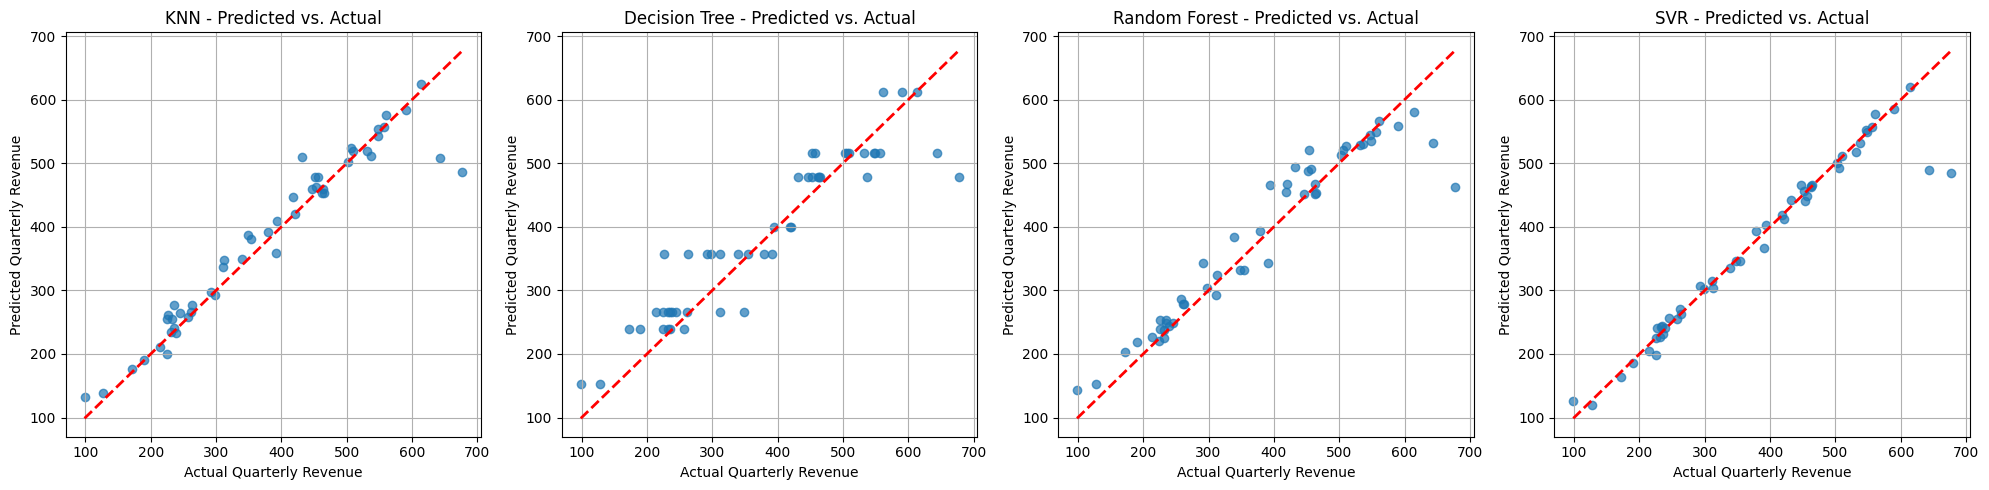

In [17]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 5))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train) # Re-fit the model
    y_pred = model.predict(X_test)

    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.7)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal prediction line
    ax.set_title(f'{name} - Predicted vs. Actual')
    ax.set_xlabel('Actual Quarterly Revenue')
    ax.set_ylabel('Predicted Quarterly Revenue')
    ax.grid(True)

plt.tight_layout()
plt.show()

From the generated visualizations and the R2 scores, the SVR (Support Vector Regressor) model appears to be the best performing. It achieved the highest R2 score of 0.94, and visually, its scattered points on the 'Predicted vs. Actual' plot are most tightly clustered around the red dashed ideal prediction line. KNN also performed very well with an R2 score of 0.93.
